In [ ]:
# pip installs
!pip install livelossplot

# Standard library imports
import os
import io
import sys
import itertools

# Third-party imports
import numpy as np
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
from tqdm import tqdm
from livelossplot import PlotLosses
from huggingface_hub import hf_hub_download
from scipy.sparse import coo_matrix
from sklearn.model_selection import train_test_split


# PyTorch imports
import torch
from torch import nn
from torch.utils.data import TensorDataset, Dataset, DataLoader, random_split
import torchvision
from torchvision.utils import make_grid
from torchvision import models
from torchsummary import summary
from torchsummary import summary
import torch.optim as optim

In [ ]:
# Mount drive
from google.colab import drive, runtime
drive.mount('/content/drive')

# Get device
device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")
    device = 'cpu'

# Function to fix random seed
def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled   = True

    return True

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cuda installed! Running on GPU!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORTANT:
#   Whenever you start a new colab runtime, use the following code to download
#   the training dataset onto the runtime local storage.
#   This should take ~3-5 mins for the whole dataset.
#   You can then load data from the local storage (/content/data) into your colab
#   notebook using the `h5py` library (see example below).
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")

'data/events.csv'

In [ ]:
# this function loads all of the image arrays for a given id
def load_event(id):
    "Load event"
    with h5py.File(f'data/train.h5','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event

event = load_event("S778114")
for img_type in event:
    print(f"{img_type}: {event[img_type].shape} ({event[img_type].dtype})")


vis: (384, 384, 36) (int16)
ir069: (192, 192, 36) (int16)
ir107: (192, 192, 36) (int16)
vil: (384, 384, 36) (uint8)
lght: (38777, 5) (float32)


In [ ]:
def load_ids(file_name="data/events.csv", frac=0.01):
    "Load ids"
    df = pd.read_csv(file_name)
    ids = df.id.unique()
    ids = np.random.choice(ids, size=int(frac*len(ids)), replace=False)
    return ids

def load_event(id):
    "Load event"
    with h5py.File(f'data/train.h5','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event

def down_sample(img, to_size):
    """
    Downsample image.

    :param img: Input image of shape [H, W, D] where D is the number of frames.
    :param to_size: Target size for downsampling (e.g., 64 for 64x64).
    :return: Downsampled image of shape [to_size, to_size, D].
    """
    if img.ndim != 3:
        raise ValueError("Input image must have 3 dimensions [H, W, D]")

    img = torch.tensor(img, dtype=torch.float32)
    # Permute to shape [D, H, W] for processing
    img = img.permute(2, 0, 1).unsqueeze(1)  # Shape: [D, 1, H, W]
    downsampled_img = torch.nn.functional.interpolate(img, size=(to_size, to_size), mode='bilinear', align_corners=False)
    # Squeeze and permute back to shape [to_size, to_size, D]
    downsampled_img = downsampled_img.squeeze(1).permute(1, 2, 0).numpy()
    return downsampled_img


def normalise_sample(img):
    """
    Normalise image to [0, 1] range.
    """
    img = img - np.min(img)
    img = img / np.max(img)
    return img


def get_targets(event):
    """
    Maps lightning strikes of an event into a sparse target mask.
    Returned targets represent lightning strikes map for each frame (36) of the event.

    :rtype: list of sparse matrices of shape (384, 384) for each frame
    """
    t = event["lght"][:,0]
    target = np.zeros((384, 384, 36))

    # For each frame in the event
    for ti in range(36):
        # Find which lightning strikes fall in current frame and store their coodinates
        f = (t >= ti*5*60) & (t < ti*5*60 + 5*60)
        xs = event["lght"][f,3]
        ys = event["lght"][f,4]

        # Set the coordinates to 1 in the target tensor
        for x, y in zip(xs, ys):
            target[int(x), int(y), ti] += 1

    return target

In [ ]:
# changing it from event by event to frame by frame

"""
Currently:
Input: (6, 144, 64, 64)
Output: (6, 36, 384, 384)
(samples, channels, pixel1, pixel2)

Change to:
Input: (36, 4, 64, 64)
Output: (36, 1, 384, 384)
(samples (all frames of an event), channels, pixel1, pixel2)

"""

'\nCurrently:\nInput: (6, 144, 64, 64)\nOutput: (6, 36, 384, 384)\n(samples, channels, pixel1, pixel2)\n\nChange to:\nInput: (36, 4, 64, 64)\nOutput: (36, 1, 384, 384)\n(samples (all frames of an event), channels, pixel1, pixel2)\n\n'

In [ ]:
# LightningDataset.py
class LightningDataset(Dataset):
    def __init__(self, ids, target_max=100):
        self.target_max = target_max
        self.events = [load_event(id) for id in ids]

        # Downsample and normalise images
        for event in self.events:
            event["vis"] = down_sample(event["vis"], to_size=64)
            event["vis"] = normalise_sample(event["vis"])
            event["vil"] = down_sample(event["vil"], to_size=64)
            event["vil"] = normalise_sample(event["vil"])
            event["ir069"] = down_sample(event["ir069"], to_size=64)
            event["ir069"] = normalise_sample(event["ir069"])
            event["ir107"] = down_sample(event["ir107"], to_size=64)
            event["ir107"] = normalise_sample(event["ir107"])

    def __len__(self):
        "Returns total number of samples"
        return len(self.events) * 36  # Assuming each event has 36 frames

    def __getitem__(self, idx):
        "Returns a single sample from the dataset"
        event_idx = idx // 36
        frame_idx = idx % 36
        event = self.events[event_idx]

        # Get the targets and normalise
        target = get_targets(event)
        target = target / self.target_max

        # Convert to PyTorch tensors and stack the image types into a single tensor
        vis = torch.tensor(event["vis"], dtype=torch.float32)
        vil = torch.tensor(event["vil"], dtype=torch.float32)
        ir069 = torch.tensor(event["ir069"], dtype=torch.float32)
        ir107 = torch.tensor(event["ir107"], dtype=torch.float32)

        vis = vis.reshape(36, 64, 64)[frame_idx]
        vil = vil.reshape(36, 64, 64)[frame_idx]
        ir069 = ir069.reshape(36, 64, 64)[frame_idx]
        ir107 = ir107.reshape(36, 64, 64)[frame_idx]

        # Stack the inputs to form a single tensor of shape (4, 64, 64)
        X = torch.stack([vis, ir069, ir107, vil], dim=0)
        # Convert dense_targets to PyTorch tensor and ensure shape is (1, 384, 384)
        Y = torch.tensor(target, dtype=torch.float32)
        Y = Y.reshape(36, 384, 384)[frame_idx].unsqueeze(0)

        return X, Y

In [ ]:
"""
Creating DataLoaders.

"""

# Load IDs and split into train and test sets
ids = load_ids(frac=0.05)
train_ids, test_ids = train_test_split(ids, test_size=0.2)

# Print the number of events
print(f"Number of training events: {len(train_ids)}")
print(f"Number of testing events: {len(test_ids)}")

# Initialize the dataset and dataloader
train_dataset = LightningDataset(train_ids)
train_dataloader = DataLoader(train_dataset, batch_size=36, shuffle=True)

val_dataset = LightningDataset(test_ids)
val_dataloader = DataLoader(val_dataset, batch_size=36, shuffle=True)


# Test the DataLoader
for X, y in train_dataloader:
    print("Training batch shapes:")
    print(X.shape)  # Should be (36, 4, 64, 64)
    print(y.shape)  # Should be (36, 1, 384, 384)
    break

for X, y in val_dataloader:
    print("Validation batch shapes:")
    print(X.shape)  # Should be (36, 4, 64, 64)
    print(y.shape)  # Should be (36, 1, 384, 384)
    break


Number of training events: 32
Number of testing events: 8
Training batch shapes:
torch.Size([36, 4, 64, 64])
torch.Size([36, 1, 384, 384])
Validation batch shapes:
torch.Size([36, 4, 64, 64])
torch.Size([36, 1, 384, 384])


In [ ]:
df = pd.read_csv("data/events.csv", parse_dates=["start_utc"])
ids = df.id.unique()
id = ids[0]


dataset = LightningDataset([id])
print(len(dataset))
print(dataset[0][0].shape)
print(dataset[0][1].shape)

36
torch.Size([4, 64, 64])
torch.Size([1, 384, 384])


In [ ]:
class UNet(nn.Module):
    def __init__(self, input_channels=4, output_channels=1):
        super(UNet, self).__init__()

        # Encoding path
        self.enc_conv1 = nn.Conv2d(input_channels, 128, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc_conv2 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec_conv1 = nn.Conv2d(512, 256,kernel_size=3, padding=1)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec_conv2 = nn.Conv2d(256, 128, kernel_size=3, padding=1)

        self.up3 = nn.ConvTranspose2d(128, 128, kernel_size=6, stride=6)
        self.dec_conv3 = nn.Conv2d(128, 64, kernel_size=3, padding=1)

        # Output layer
        self.output_layer = nn.Conv2d(64, output_channels, kernel_size=1)  # Linear activation (no ReLU)

    def forward(self, x):
        # Encoding path
        enc1 = torch.relu(self.enc_conv1(x))
        pool1 = self.pool1(enc1)

        enc2 = torch.relu(self.enc_conv2(pool1))
        pool2 = self.pool2(enc2)

        # Bottleneck
        bottleneck = torch.relu(self.bottleneck(pool2))

        # Decoding path using transposed convolutions
        up1 = self.up1(bottleneck)
        concat1 = torch.cat([up1, enc2], dim=1)
        dec1 = torch.relu(self.dec_conv1(concat1))

        up2 = self.up2(dec1)
        concat2 = torch.cat([up2, enc1], dim=1)
        dec2 = torch.relu(self.dec_conv2(concat2))

        up3 = self.up3(dec2)
        dec3 = torch.relu(self.dec_conv3(up3))

        # Output layer (applied sigmoid to ensure output is between 0 and 1)
        outputs = torch.sigmoid(self.output_layer(dec3))
        return outputs

In [ ]:
model = UNet()

# Example input tensor
batch_size = 36
features_per_frame = 4  # Assuming 4 features per frame
height, width = 64, 64

# Creating input in (batch, channels, height, width) format
example_input = torch.randn(batch_size, features_per_frame, height, width)
print(example_input.shape)

# Forward pass
output = model(example_input)
print("Output shape:", output.shape)  # Expected: (1, 36, 384, 384)

torch.Size([36, 4, 64, 64])
Output shape: torch.Size([36, 1, 384, 384])


In [ ]:
from torchvision import models
from torchsummary import summary
from torchsummary import summary


input_channels = 4
output_channels = 1
model = UNet(input_channels=input_channels, output_channels=output_channels)
summary(model, input_size=(4, 64, 64), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 64, 64]           4,736
         MaxPool2d-2          [-1, 128, 32, 32]               0
            Conv2d-3          [-1, 256, 32, 32]         295,168
         MaxPool2d-4          [-1, 256, 16, 16]               0
            Conv2d-5          [-1, 512, 16, 16]       1,180,160
   ConvTranspose2d-6          [-1, 256, 32, 32]         524,544
            Conv2d-7          [-1, 256, 32, 32]       1,179,904
   ConvTranspose2d-8          [-1, 128, 64, 64]         131,200
            Conv2d-9          [-1, 128, 64, 64]         295,040
  ConvTranspose2d-10        [-1, 128, 384, 384]         589,952
           Conv2d-11         [-1, 64, 384, 384]          73,792
           Conv2d-12          [-1, 1, 384, 384]              65
Total params: 4,274,561
Trainable params: 4,274,561
Non-trainable params: 0
---------------------------

In [ ]:

from torch.utils.data import DataLoader
import random

batch_size = 36

# Load IDs and split into train and test sets
ids = load_ids(frac=0.1)
train_ids, val_ids = train_test_split(ids, test_size=0.8)

# Initialize the dataset
train_dataset = LightningDataset(train_ids, target_max=100)
val_dataset = LightningDataset(val_ids, target_max=100)

# Create DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


max normalised lightining in frame 1:  tensor(0.0500)


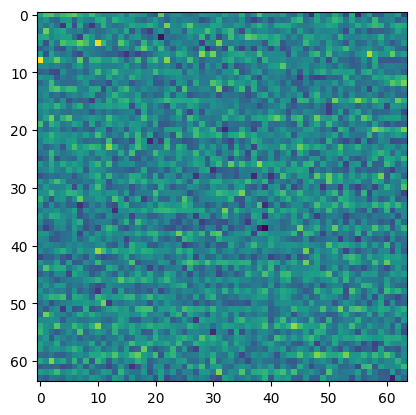

In [ ]:
# Get validation sample
input_sample, target_sample = next(iter(val_loader))
input_sample.shape

sample_image = input_sample[0,0,:,:].reshape(64,64)
plt.imshow(sample_image)
print("max normalised lightining in frame 1: ", torch.max(target_sample[0][0]))

In [ ]:
# Custom Total Absolute Error Loss
class TotalAbsoluteError(nn.Module):
    def __init__(self):
        super(TotalAbsoluteError, self).__init__()

    def forward(self, input, target):
        # Compute the absolute error
        absolute_error = torch.abs(input - target)
        # Sum up all the absolute errors
        total_absolute_error = absolute_error.sum()
        return total_absolute_error

In [ ]:
import torch.optim as optim

# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the U-Net model and move it to the selected device
model = UNet().to(device)

# Define the loss function and optimizer
criterion = TotalAbsoluteError()  # Mean squared error for regression tasks
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Store loss values for plotting
train_losses = []
val_losses = []

# Training loop with loss tracking
num_epochs = 10

for epoch in range(num_epochs):
    print(f"Epoch:{epoch}")
    model.train()
    running_loss = 0.0
    for input, target in train_loader:
        input, target = input.to(device), target.to(device)
        # Forward pass
        optimizer.zero_grad()
        output = model(input)
        # Calculate loss
        loss = criterion(output, target)
        running_loss += loss.item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

    # Calculate training loss
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss}")

    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for input, target in val_loader:
            input, target = input.to(device), target.to(device)

            # Forward pass
            output = model(input)
            loss = criterion(output, target)
            val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss}")

Using device: cuda
Epoch:0
Epoch [1/10], Training Loss: 2494151.3125
Validation Loss: 2213152.01953125
Epoch:1
Epoch [2/10], Training Loss: 681867.3856525421
Validation Loss: 280.2251180410385
Epoch:2
Epoch [3/10], Training Loss: 137.59135627746582
Validation Loss: 76.25352723663673
Epoch:3
Epoch [4/10], Training Loss: 107.15243434906006
Validation Loss: 75.51726900434005
Epoch:4
Epoch [5/10], Training Loss: 106.91756200790405
Validation Loss: 75.45174587020301
Epoch:5
Epoch [6/10], Training Loss: 106.8868293762207
Validation Loss: 75.43073024040496
Epoch:6
Epoch [7/10], Training Loss: 106.87258434295654
Validation Loss: 75.41523700326798
Epoch:7
Epoch [8/10], Training Loss: 106.86060047149658
Validation Loss: 75.40081535483478
Epoch:8
Epoch [9/10], Training Loss: 106.84970331192017
Validation Loss: 75.38797133032494
Epoch:9
Epoch [10/10], Training Loss: 106.84030485153198
Validation Loss: 75.37752670952614


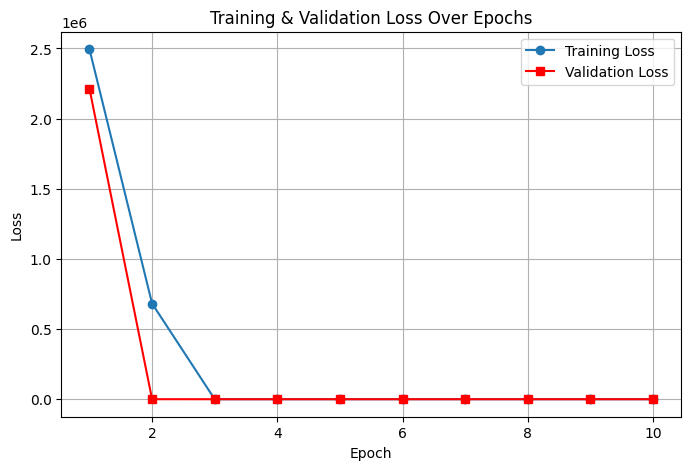

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', label="Training Loss")
plt.plot(range(1, num_epochs + 1), val_losses, marker='s', linestyle='-', color='red', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.show()

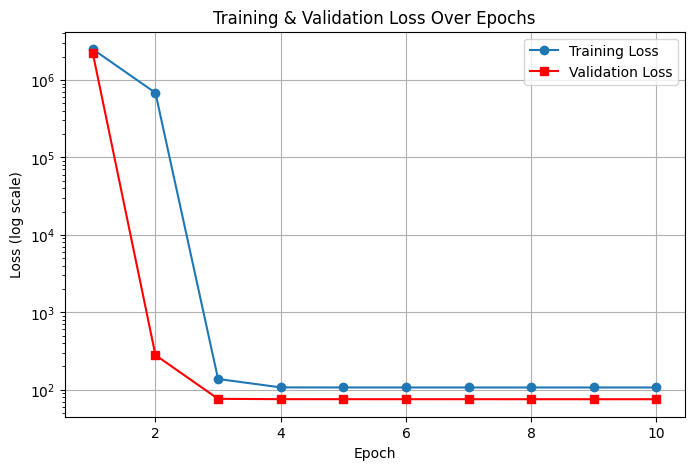

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', label="Training Loss")
plt.plot(range(1, num_epochs + 1), val_losses, marker='s', linestyle='-', color='red', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Training & Validation Loss Over Epochs")
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# event id to plot
index = 0
m_id = ids[index]

m_event = load_event(m_id)
event_targets = get_targets(m_event)

predict_events = [ids[idx] for idx in range(index, batch_size)]
predict_dataset = LightningDataset(predict_events, target_max=100)
predict_loader = DataLoader(predict_dataset, batch_size=batch_size, shuffle=True)


for X_next, y_next in predict_loader:
  print(X_next.shape, y_next.shape)
  prediction_batch = model(X_next.to(device)).detach().cpu()
  break


tensor_label = torch.tensor(event_targets).reshape(36, 384, 384)


# plotting label and target
def plot_label_prediction(label, prediction):
  fig, axs = plt.subplots(1, 2, figsize=(10, 5))
  axs[0].imshow(label)
  axs[1].imshow(prediction)
  plt.show()

# plot all 36 frames (all of the batch)
for i in range(36):
  event1_pred = prediction_batch[i]
  event1_pred *= 100
  # prediction information
  print("\nAT FRAME", i)
  print("PREDICTION INFORMATION")
  print(prediction_batch.shape)
  print("sum: ", torch.sum(event1_pred))
  print("max: ", torch.max(event1_pred))
  print("mean: ", torch.mean(event1_pred))

  # target information
  print("\nTARGET INFORMATION")
  print("sum: ", torch.sum(tensor_label[i]))
  print("max: ", torch.max(tensor_label[i]))
  print("mean: ", torch.mean(tensor_label[i]))


# for i in range(36):
#   if i%4 == 0:

#     event1_pred = prediction_batch[i]
#     event1_pred *= 100
#     plot_label_prediction(tensor_label[i], event1_pred[0])



print("\n\n ONLY TOTAL LIGHTNINGS PER FRAME")
for i in range(36):
  event1_pred = prediction_batch[i]
  event1_pred *= 100
  print(f"frame{i}, prediction:{torch.sum(event1_pred[0])}, target:{torch.sum(tensor_label[i])}")



# print("\nCOMPARINS SMALL SECTIONS OF THE PREDICTION AND LABEL")
# for i in range(36):
#   loss = torch.nn.functional.mse_loss(event1_pred[i], tensor_label[i])
#   if (loss != 0):
#     print("i: ", i)
#     print(loss)

torch.Size([36, 4, 64, 64]) torch.Size([36, 1, 384, 384])

AT FRAME 0
PREDICTION INFORMATION
torch.Size([36, 1, 384, 384])
sum:  tensor(0.0912)
max:  tensor(0.0377)
mean:  tensor(6.1871e-07)

TARGET INFORMATION
sum:  tensor(262., dtype=torch.float64)
max:  tensor(8., dtype=torch.float64)
mean:  tensor(0.0018, dtype=torch.float64)

AT FRAME 1
PREDICTION INFORMATION
torch.Size([36, 1, 384, 384])
sum:  tensor(0.0297)
max:  tensor(0.0096)
mean:  tensor(2.0158e-07)

TARGET INFORMATION
sum:  tensor(112., dtype=torch.float64)
max:  tensor(2., dtype=torch.float64)
mean:  tensor(0.0008, dtype=torch.float64)

AT FRAME 2
PREDICTION INFORMATION
torch.Size([36, 1, 384, 384])
sum:  tensor(0.0784)
max:  tensor(0.0275)
mean:  tensor(5.3193e-07)

TARGET INFORMATION
sum:  tensor(84., dtype=torch.float64)
max:  tensor(2., dtype=torch.float64)
mean:  tensor(0.0006, dtype=torch.float64)

AT FRAME 3
PREDICTION INFORMATION
torch.Size([36, 1, 384, 384])
sum:  tensor(0.7569)
max:  tensor(0.2641)
mean:  tensor(

tensor(0.)
tensor(0.0027)


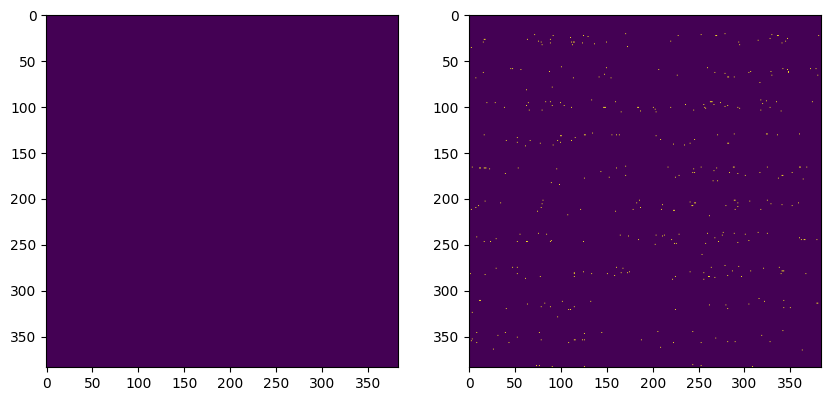

In [ ]:
## Get model ouput on validation
# Get sample and output
input, target = next(iter(train_loader))
input = input.to(device)
output = model(input)
output = output.detach().cpu()

# Set all values each frame not equal to zero to 1
test_output = output[0, 0, :, :].reshape(384, 384)
test_target = target[0, 0, :, :].reshape(384, 384)

test_output *= 100
test_target *= 100
test_output[test_output < 1] = 0
test_output[test_output >= 1] = 1
test_target[test_target >= 1] = 1

# Plot output vs target
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
print(torch.mean(test_output))
print(torch.mean(test_target))
axs[0].imshow(test_output)
axs[1].imshow(test_target)

# FRAMEWORK TO VISUALISE MODEL PREDICTIONS
1. Frame by Frame: predict_plot
2. Event GIF: predict_plot_w_gif

In [ ]:
# 1: creating a lightning maps (target) from a given lightning time series
# 2: creating a lightining time series (output) from predicted lightning maps (36 per event/sample)
def get_targets(event):
    """
    Maps lightning strikes of an event into a sparse target mask.
    Returned targets represent lightning strikes map for each frame (36) of the event.

    :rtype: list of sparse matrices of shape (384, 384) for each frame
    """
    t = event["lght"][:,0]
    target = np.zeros((384, 384, 36))

    # For each frame in the event
    for ti in range(36):
        # Find which lightning strikes fall in current frame and store their coodinates
        f = (t >= ti*5*60) & (t < ti*5*60 + 5*60)
        xs = event["lght"][f,3]
        ys = event["lght"][f,4]

        # Set the coordinates to 1 in the target tensor
        for x, y in zip(xs, ys):
            target[int(x), int(y), ti] += 1

    return target


def get_lightning_time_series(prediction):
    """
    Converts the given prediction (36 lightning maps of 36 frames of an event)
    into a ligthning time series of that event.

    :param target: list of sparse matrices of shape (384, 384, 36) representing lightning strikes map for each frame
    :rtype: lightning time series of that prediction/event.
    """
    lght = []
    n_frames = 36 # assumes 36 frames
    # lightining strike values (in the map) above masked
    # value are considered as lightnings
    mask_value = 1

    # For each frame in the target
    prediction = prediction.reshape(384, 384, n_frames)
    for ti in range(n_frames):
        frame = prediction[:, :, ti]
        xs, ys = np.where(frame >= mask_value)

        # For each lightning strike in the frame
        for x, y in zip(xs, ys):
            count = frame[x, y]
            count = 1 if count > 0 else 0 # only store one lightning per location for now
            for _ in range(int(count)):
                lght.append([ti * 5 * 60, 0, 0, x, y])

    lght = np.array(lght)
    return lght

In [ ]:
# create a testing framework
# given an event, predict the answer

def predict_event(event_id_idx):
  """
  Designed for U-NET arhictecture
  This predicter assumes model output: (36, 1, 384, 384)
  1 sample = 1 event (36 frames, 36 lightning maps)

  Input: id of the event to predict
  Output: predicted lightning time series of that event
  """
  # creating a dataloader for the event (+ remaining batch size)
  predict_events = [ids[idx] for idx in range(event_id_idx, batch_size)]
  predict_dataset = LightningDataset(predict_events, target_max=100)
  predict_loader = DataLoader(predict_dataset, batch_size=batch_size, shuffle=True)

  # only predicting the first sample in the batch (to match our event)
  for X_next, y_next in predict_loader:
    prediction_batch = model(X_next.to(device)).detach().cpu()
    break

  lightning_maps_output = prediction_batch.reshape(36, 384, 384)
  lightning_maps_output *= 100 # denormalise

  # creating lightning time series from lightning maps (36 maps per sample/event)
  ligthning_ts = get_lightning_time_series(lightning_maps_output)
  return ligthning_ts



In [ ]:
""" EVENT PLOTS WITH PREDICTIONS PER FRAME """
def plot_event_w_predictions(event, predicted_lght, frame=0):
    """
    Plots the event with 4 input image channels
    Plots target/label lightning strikes of the event
    Plots predicted/output lightning strikes of the event
    """

    t = event["lght"][:,0]# time of lightning strike (in seconds relative to first frame)
    if len(predicted_lght) != 0: t_pred = predicted_lght[:,0]

    def plot_frame(ti):
        f = (t >= ti*5*60 - 2.5*60) & (t < ti*5*60 + 2.5*60)# find which lightning strikes fall in current frame
        if len(predicted_lght) != 0: f_pred =  (t_pred >= ti*5*60 - 2.5*60) & (t_pred < ti*5*60 + 2.5*60)

        fig,axs = plt.subplots(1,5,figsize=(16,5))
        fig.suptitle(f"Event: {id}, Frame: {ti}, Time: {ti*5} min")
        axs[0].imshow(event["vis"][:,:,ti], vmin=0, vmax=10000, cmap="grey"), axs[0].set_title('Visible')
        axs[1].imshow(event["ir069"][:,:,ti], vmin=-8000, vmax=-1000, cmap="viridis"), axs[1].set_title('Infrared (Water Vapor)')
        axs[2].imshow(event["ir107"][:,:,ti], vmin=-7000, vmax=2000, cmap="inferno"), axs[2].set_title('Infrared (Cloud/Surface Temperature)')
        axs[3].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[3].set_title('Radar')
        axs[3].scatter(event["lght"][f,3], event["lght"][f,4], marker="x", s=30, c="tab:red")
        axs[3].set_xlim(0,384), axs[3].set_ylim(384,0)

        axs[4].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[4].set_title('Radar Predicted Strikes')
        if len(predicted_lght) != 0:
          axs[4].scatter(predicted_lght[f_pred,3], predicted_lght[f_pred,4], marker="x", s=30, c="tab:red")
          axs[4].set_xlim(0,384), axs[3].set_ylim(384,0)
        plt.show()

    plot_frame(frame)


""" EVENT PLOT WITH PREDICTIONS PER EVENT (GIF) """
def make_gif(outfile, files, fps=10, loop=0):
    "Helper function for saving GIFs"
    imgs = [PIL.Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='gif', append_images=imgs[1:],
                 save_all=True, duration=int(1000/fps), loop=loop)
    im = IPython.display.Image(filename=outfile)
    im.reload()
    return im


def plot_event_w_predictions_gif(event, predicted_lght output_gif=False, save_gif=False):
    t = event["lght"][:,0]# time of lightning strike (in seconds relative to first frame)
    if len(predicted_lght) != 0: t_pred = predicted_lght[:,0]

    def plot_frame(ti):
        f = (t >= ti*5*60 - 2.5*60) & (t < ti*5*60 + 2.5*60)# find which lightning strikes fall in current frame
        if len(predicted_lght) != 0: f_pred =  (t_pred >= ti*5*60 - 2.5*60) & (t_pred < ti*5*60 + 2.5*60)

        fig,axs = plt.subplots(1,5,figsize=(16,5))
        fig.suptitle(f"Event: {id}, Frame: {ti}, Time: {ti*5} min")
        axs[0].imshow(event["vis"][:,:,ti], vmin=0, vmax=10000, cmap="grey"), axs[0].set_title('Visible')
        axs[1].imshow(event["ir069"][:,:,ti], vmin=-8000, vmax=-1000, cmap="viridis"), axs[1].set_title('Infrared (Water Vapor)')
        axs[2].imshow(event["ir107"][:,:,ti], vmin=-7000, vmax=2000, cmap="inferno"), axs[2].set_title('Infrared (Cloud/Surface Temperature)')
        axs[3].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[3].set_title('Radar')
        axs[3].scatter(event["lght"][f,3], event["lght"][f,4], marker="x", s=30, c="tab:red")
        axs[3].set_xlim(0,384), axs[3].set_ylim(384,0)

        axs[4].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[4].set_title('Radar Predicted Strikes')
        if len(predicted_lght) != 0:
          axs[4].scatter(predicted_lght[f_pred,3], predicted_lght[f_pred,4], marker="x", s=30, c="tab:red")
          axs[4].set_xlim(0,384), axs[3].set_ylim(384,0)

        if output_gif:
            file = f"_temp_{id}_{ti}.png"
            fig.savefig(file, bbox_inches="tight", dpi=150, pad_inches=0.02, facecolor="white")
            plt.close()
        else:
            plt.show()

    if output_gif:
        for ti in range(36): plot_frame(ti)
        im = make_gif(f"{id}.gif", [f"_temp_{id}_{ti}.png" for ti in range(36)])
        for ti in range(36): os.remove(f"_temp_{id}_{ti}.png")
        IPython.display.display(im)
        if not save_gif: os.remove(f"{id}.gif")
    else:
        plot_frame(0)
        plot_frame(17)
        plot_frame(34)


In [ ]:
# predict an event, plot the event and predictions
def predict_plot(event_id_idx):
  """
  Predicts and plots the given event based on event id index.
  """

  # loading the event
  m_id = ids[event_id_idx]
  m_event = load_event(m_id)
  # predicting the event, getting predicted lightining time series
  predicted_lght = predict_event(event_id_idx)
  print("number of predicted lightnings: ", len(predicted_lght))

  # plotting the event along with predicted lightining time series
  plot_event_w_predictions(m_event, predicted_lght, frame=0)


def predict_plot_w_gif(event_id_idx):
    """
    Predicts and plots a gif the given event based on event id index.
    """

    # loading the event
    m_id = ids[event_id_idx]
    m_event = load_event(m_id)
    # predicting the event, getting predicted lightining time series
    predicted_lght = predict_event(event_id_idx)
    print("number of predicted lightnings: ", len(predicted_lght))

    # plotting the event along with predicted lightining time series
    plot_event_w_predictions_gif(m_event, predicted_lght, output_gif=True, save_gif=True)

number of predicted lightnings:  0


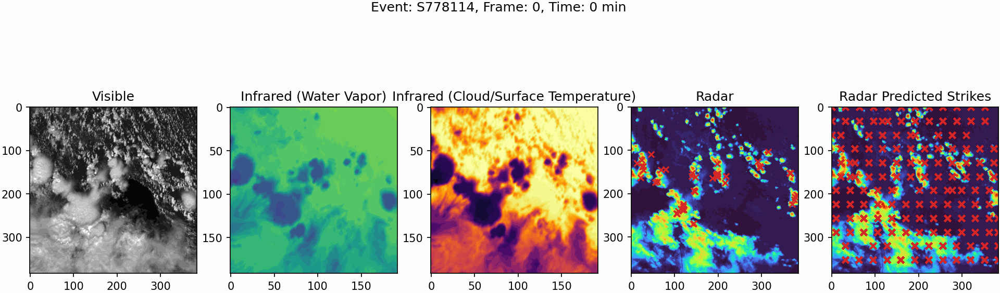

In [ ]:
#predict_plot(0) # predicting and plotting the event with event id idx = 0
predict_plot_w_gif(0) # predicting and plotting the event gif with even id idx = 0